### **PART 01. Data Imputation and Feature Selection**
**Objective:** To resolve data gaps using a mathematically validated **$K$-Nearest Neighbors (KNN)** strategy and eliminate multicollinearity to ensure model interpretability.

#### **01. Initial Configuration and Data Alignment**

Load the preliminary dataset generated by the `data_ingestion.py` script and encode categorical features, such as the $pod$ (Part of Day) value, as numeric values. This transformation is required for the subsequent distance-based calculations used in the KNN Imputation phase.

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# --- CONFIGURATION ---
ROOT_DIR = os.path.dirname(os.getcwd())
DATA_PROCESSED = os.path.join(ROOT_DIR, "data", "processed")
DATA_FINAL = os.path.join(ROOT_DIR, "data", "final")

In [ ]:
# Load the dataset
df = pd.read_csv(os.path.join(DATA_PROCESSED, "data_cleaned.csv"))

# Convert timestamp to datetime and set as index 
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'])
df.set_index('timestamp_local', inplace=True) 

print("Initial DataFrame shape:", df.shape)
df.head()

Initial DataFrame shape: (36480, 27)


,app_temp,azimuth,clouds,dewpt,dhi,dni,elev_angle,ghi,pod,precip,...,wind_dir,wind_gust_spd,wind_spd,aqi,co,no2,o3,pm10,pm25,so2
timestamp_local,,,,,,,,,,,,,,,,,,,,,
2022-01-13 00:00:00,17.0,239.9,100,15.9,0,0,-88.6,0,n,0.0,...,106,2.4,1.6,180.0,381.3,16.7,86.7,109.3,77.67,54.7
2022-01-13 01:00:00,16.8,95.5,100,16.3,0,0,-77.2,0,n,0.0,...,98,2.0,1.2,181.0,389.8,17.0,87.0,111.0,79.00,59.0
2022-01-13 02:00:00,16.4,96.7,91,16.0,0,0,-63.3,0,n,0.0,...,78,2.0,1.2,178.0,385.0,16.0,87.3,107.3,76.33,58.7
2022-01-13 03:00:00,16.1,99.2,83,15.6,0,0,-49.4,0,n,0.0,...,58,2.4,1.2,174.0,380.1,15.0,87.7,103.7,73.67,58.3
2022-01-13 04:00:00,15.7,102.2,75,15.2,0,0,-35.7,0,n,0.0,...,46,3.2,1.6,171.0,375.3,14.0,88.0,100.0,71.00,58.0


In [13]:
# Encoding categorical features for pod (Part of Day) column
# Binary Encoding: Day = 1, Night = 0
df['pod'] = df['pod'].map({'d': 1, 'n': 0})
df[['pod']].iloc[:10]

,pod
timestamp_local,
2022-01-13 00:00:00,0
2022-01-13 01:00:00,0
2022-01-13 02:00:00,0
2022-01-13 03:00:00,0
2022-01-13 04:00:00,0
2022-01-13 05:00:00,0
2022-01-13 06:00:00,0
2022-01-13 07:00:00,1
2022-01-13 08:00:00,1


#### **02. Data Integrity Audit & Missingness Analysis**

Quantification of the frequency and distribution of missing values is performed across all features. Identification of temporal gaps evaluates the continuity of the time-series data. This analysis provides the statistical context required to assess the dataset's structure before the imputation phase and validates the initial selection of features for the distance-calculation process.

In [14]:
# Calculate missingness percentage
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100

missing_stats = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_pct
}).sort_values(by='Percentage (%)', ascending=False)

print("Missing Data Statistics:")
missing_stats[missing_stats['Missing Values'] > 0]

Missing Data Statistics:


,Missing Values,Percentage (%)
so2,78,0.213816
o3,78,0.213816
no2,77,0.211075
co,77,0.211075
vis,7,0.019189
pm25,4,0.010965
pm10,4,0.010965
aqi,4,0.010965


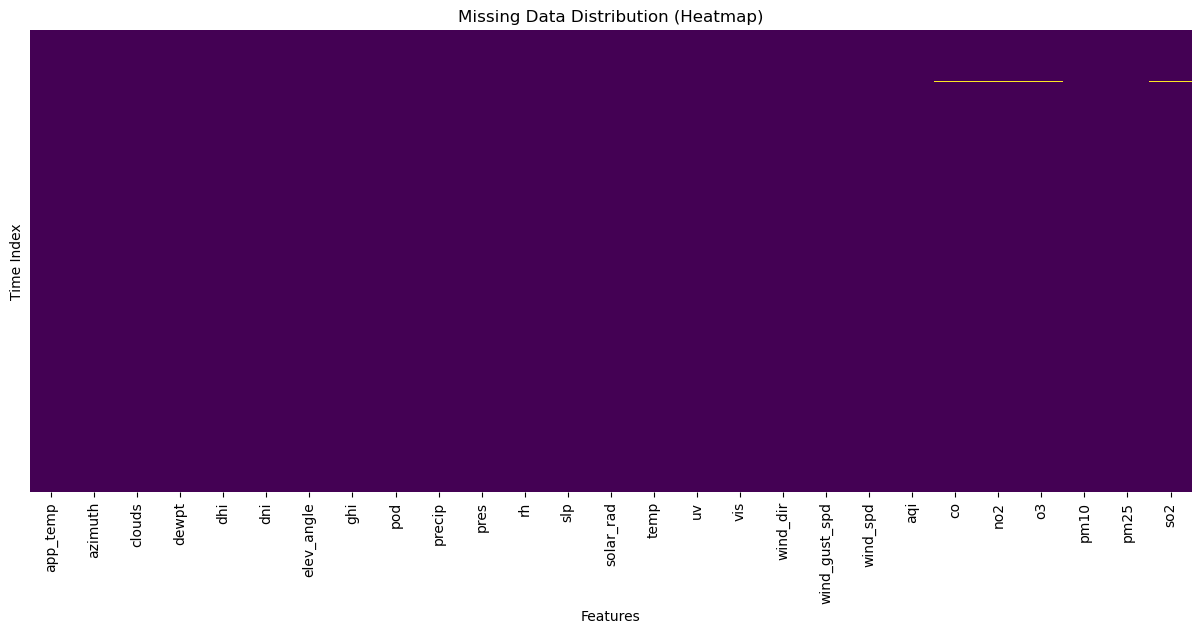

In [5]:
# Mapping temporal gaps to distinguish between random fluctuations and prolonged blackouts
plt.figure(figsize=(15, 6))
# cmap='viridis' makes nulls stand out as bright yellow/purple
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Distribution (Heatmap)')
plt.xlabel('Features')
plt.ylabel('Time Index')
plt.show()

The heatmap reveals that missingness is localized to a few specific temporal points, predominantly affecting air quality metrics simultaneously. The high ratio of purple to yellow confirms sufficient neighbor density for reliable KNN imputation, with no evidence of prolonged data blackouts that would undermine time-series continuity.

In [15]:
# Identification of the maximum gap length and location to evaluate time-series continuity
def analyze_temporal_gaps(df):
    gap_report = []
    
    if 'timestamp_local' in df.columns:
        time_data = df['timestamp_local']
    else:
        time_data = df.index.to_series()

    for col in df.select_dtypes(include=[np.number]).columns:
        is_null = df[col].isnull()
        if is_null.any():
            # Identify consecutive groups
            gap_id = (is_null != is_null.shift()).cumsum()
            # Filter to only look at null groups
            null_gaps = is_null[is_null]

            if not null_gaps.empty:
                # Count sizes of each null group
                gaps_sizes = null_gaps.groupby(gap_id[is_null]).size()

                max_gap = gaps_sizes.max()
                ave_gap = gaps_sizes.mean()

                # Find the start/end times for the largest gap
                max_gap_id = gaps_sizes.idxmax()
                
                # Use boolean indexing to get the timestamps for the max gap
                max_gap_timestamps = time_data[gap_id == max_gap_id]
                
                start_time = max_gap_timestamps.iloc[0]
                end_time = max_gap_timestamps.iloc[-1]

                gap_report.append({
                    'Feature': col,
                    'Max Gap (Hours)': max_gap,
                    'Average Gap (Hours)': round(ave_gap, 2),
                    'Max Gap Start': start_time,
                    'Max Gap End': end_time
                })

    return pd.DataFrame(gap_report).sort_values(by='Max Gap (Hours)', ascending=False)

print("Temporal Gap Analysis:")
analyze_temporal_gaps(df)

Temporal Gap Analysis:


,Feature,Max Gap (Hours),Average Gap (Hours),Max Gap Start,Max Gap End
2,co,74,19.25,2022-06-30 05:00:00,2022-07-03 06:00:00
3,no2,74,19.25,2022-06-30 05:00:00,2022-07-03 06:00:00
4,o3,74,15.60,2022-06-30 05:00:00,2022-07-03 06:00:00
7,so2,74,15.60,2022-06-30 05:00:00,2022-07-03 06:00:00
0,vis,3,1.40,2025-09-02 17:00:00,2025-09-02 19:00:00
1,aqi,2,1.33,2022-07-01 06:00:00,2022-07-01 07:00:00
5,pm10,2,1.33,2022-07-01 06:00:00,2022-07-01 07:00:00
6,pm25,2,1.33,2022-07-01 06:00:00,2022-07-01 07:00:00


#### **03. Scaling and KNN Imputation**

The **$K$-Nearest Neighbors (KNN)** algorithm is distance-based, typically calculating the **Euclidean distance** between data points. Because features possess varying ranges, larger numerical values (like $CO$) mathematically dominate distance calculations if left unscaled.

**Min-Max Scaling** is applied to compress all features into a uniform range of $[0, 1]$ so that each variable contributes equally to the imputation process:

$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

In [16]:
# Feature Scaling: Min-Max Normalization
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

Prior to the final imputation, the optimal value for $k$ must be determined. This is achieved by selecting a "complete" subset of the data, artificially masking 10% of the values, and testing which $k$ predicts those values with the lowest **Normalized Root Mean Square Error (NRMSE)**.

In [17]:
# Identify all columns that contain at least one missing value
missing_cols = df.columns[df.isnull().any()].tolist()
print("Columns with missing values:", missing_cols)
df_complete = df_scaled.dropna()

# Artificially mask 10% of the data across all these columns
df_validation = df_complete.copy()
np.random.seed(42)  # For reproducibility
# Create a random mask for the entire dataframe subset
mask = np.random.rand(*df_validation.shape) < 0.1
df_validation[mask] = np.nan

# Comprehensive Grid Search for Optimal k in KNN Imputation
k_values = [3, 5, 7, 9, 11]
total_nrmse = []

print("Optimizing k-Neighbors...")

for k in k_values:
    imputer_test = KNNImputer(n_neighbors=k, weights='distance')
    imputed_test = imputer_test.fit_transform(df_validation)
    df_res = pd.DataFrame(imputed_test, columns=df.columns)
    
    k_column_errors = []
    for col in missing_cols:
        col_idx = df.columns.get_loc(col)
        y_true = df_complete.iloc[:, col_idx]
        y_pred = df_res.iloc[:, col_idx]

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Normalize RMSE by the range of the column
        col_range = y_true.max() - y_true.min()
        nrmse = rmse / col_range if col_range != 0 else rmse

        k_column_errors.append(nrmse)
    
    # The final score for this k is the average NRMSE across all columns
    mean_k_error = np.mean(k_column_errors)
    total_nrmse.append(mean_k_error)
    print(f"k={k}: Average NRMSE = {mean_k_error:.4f}")


Columns with missing values: ['vis', 'aqi', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2']
Optimizing k-Neighbors...
k=3: Average NRMSE = 0.0189
k=5: Average NRMSE = 0.0185
k=7: Average NRMSE = 0.0186
k=9: Average NRMSE = 0.0187
k=11: Average NRMSE = 0.0189


Optimal k-value: 5


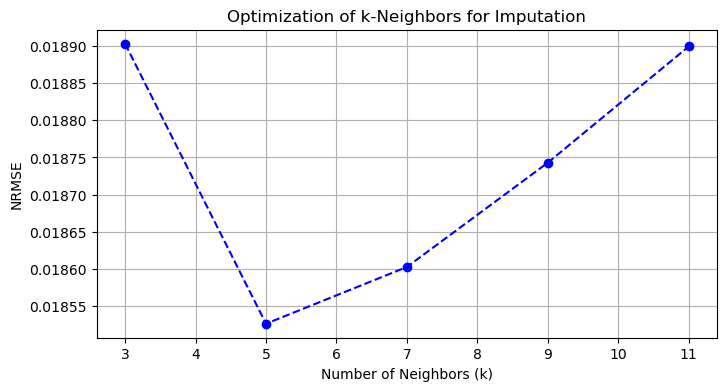

In [18]:
# Identification and visualization of the optimal k-value
optimal_k = k_values[np.argmin(total_nrmse)]
print(f"Optimal k-value: {optimal_k}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, total_nrmse, marker='o', linestyle='--', color='b')
plt.title("Optimization of k-Neighbors for Imputation")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("NRMSE")
plt.grid(True)
plt.show()

In [19]:
# Final Imputation with Optimal k
final_imputer = KNNImputer(n_neighbors=optimal_k, weights='distance')
print(df_scaled.columns[df_scaled.isnull().any()].tolist())
imputed_array = final_imputer.fit_transform(df_scaled)

# Restore original units
final_data = scaler.inverse_transform(imputed_array)
df_imputed = pd.DataFrame(final_data, columns=df.columns, index=df.index)

['vis', 'aqi', 'co', 'no2', 'o3', 'pm10', 'pm25', 'so2']


In [24]:
# Print imputed values for originally missing entries
print("Imputed values for originally missing entries:")
for col in missing_cols:
    # Identify indices where data was originally missing
    missing_indices = df.index[df[col].isnull()]
    # Extract the values that the KNN imputer placed in those holes
    imputed_block = df_imputed.loc[missing_indices, col]
    print(f"Feature: {col.upper()}")
    print(f"Total entries filled: {len(imputed_block)}")

    if len(imputed_block) > 0:
        # Statistical summary of the imputed values
        stats = imputed_block.describe()
        print(f"Stats: Mean={stats['mean']:.2f}, Min={stats['min']:.2f}, Max={stats['max']:.2f}")

        # Display the few imputed values
        print(imputed_block.head())
    
    print(f"\n{'-' * 30}")

Imputed values for originally missing entries:
Feature: VIS
Total entries filled: 7
Stats: Mean=10.08, Min=8.83, Max=12.01
timestamp_local
2025-08-25 00:00:00     9.056187
2025-08-29 01:00:00     9.696383
2025-08-29 06:00:00    10.972416
2025-09-02 17:00:00    12.011710
2025-09-02 18:00:00    10.000000
Name: vis, dtype: float64

------------------------------
Feature: AQI
Total entries filled: 4
Stats: Mean=111.26, Min=91.42, Max=135.30
timestamp_local
2022-07-01 06:00:00    113.421079
2022-07-01 07:00:00    104.893518
2024-12-13 00:00:00    135.299047
2025-04-13 00:00:00     91.420026
Name: aqi, dtype: float64

------------------------------
Feature: CO
Total entries filled: 77
Stats: Mean=688.37, Min=90.73, Max=1696.53
timestamp_local
2022-06-30 05:00:00    203.570634
2022-06-30 06:00:00    555.957014
2022-06-30 07:00:00    360.673770
2022-06-30 08:00:00    390.065591
2022-06-30 09:00:00    288.978626
Name: co, dtype: float64

------------------------------
Feature: NO2
Total entries

In [27]:
# Save the imputed dataset to the final directory by adding the new values to preserve any original non-missing data
df_final = df.copy()
for col in missing_cols:
    missing_indices = df.index[df[col].isnull()]
    df_final.loc[missing_indices, col] = df_imputed.loc[missing_indices, col]

# Verify that there are no missing values left
print("Missing values after imputation:", df_final.isnull().sum().sum())
# Save the final imputed dataset
df_final.to_csv(os.path.join(DATA_PROCESSED, "data_imputed.csv"), index=True)
df_final.head()


Missing values after imputation: 0


,app_temp,azimuth,clouds,dewpt,dhi,dni,elev_angle,ghi,pod,precip,...,wind_dir,wind_gust_spd,wind_spd,aqi,co,no2,o3,pm10,pm25,so2
timestamp_local,,,,,,,,,,,,,,,,,,,,,
2022-01-13 00:00:00,17.0,239.9,100,15.9,0,0,-88.6,0,0,0.0,...,106,2.4,1.6,180.0,381.3,16.7,86.7,109.3,77.67,54.7
2022-01-13 01:00:00,16.8,95.5,100,16.3,0,0,-77.2,0,0,0.0,...,98,2.0,1.2,181.0,389.8,17.0,87.0,111.0,79.00,59.0
2022-01-13 02:00:00,16.4,96.7,91,16.0,0,0,-63.3,0,0,0.0,...,78,2.0,1.2,178.0,385.0,16.0,87.3,107.3,76.33,58.7
2022-01-13 03:00:00,16.1,99.2,83,15.6,0,0,-49.4,0,0,0.0,...,58,2.4,1.2,174.0,380.1,15.0,87.7,103.7,73.67,58.3
2022-01-13 04:00:00,15.7,102.2,75,15.2,0,0,-35.7,0,0,0.0,...,46,3.2,1.6,171.0,375.3,14.0,88.0,100.0,71.00,58.0


#### **04. Diagnostic Heatmap and Feature Selection**

A **Pearson correlation matrix** is generated to visualize the linear relationships between all features. In the context of the Hanoi atmospheric dataset, the primary objective is to identify redundant pairs where two variables provide nearly identical information.

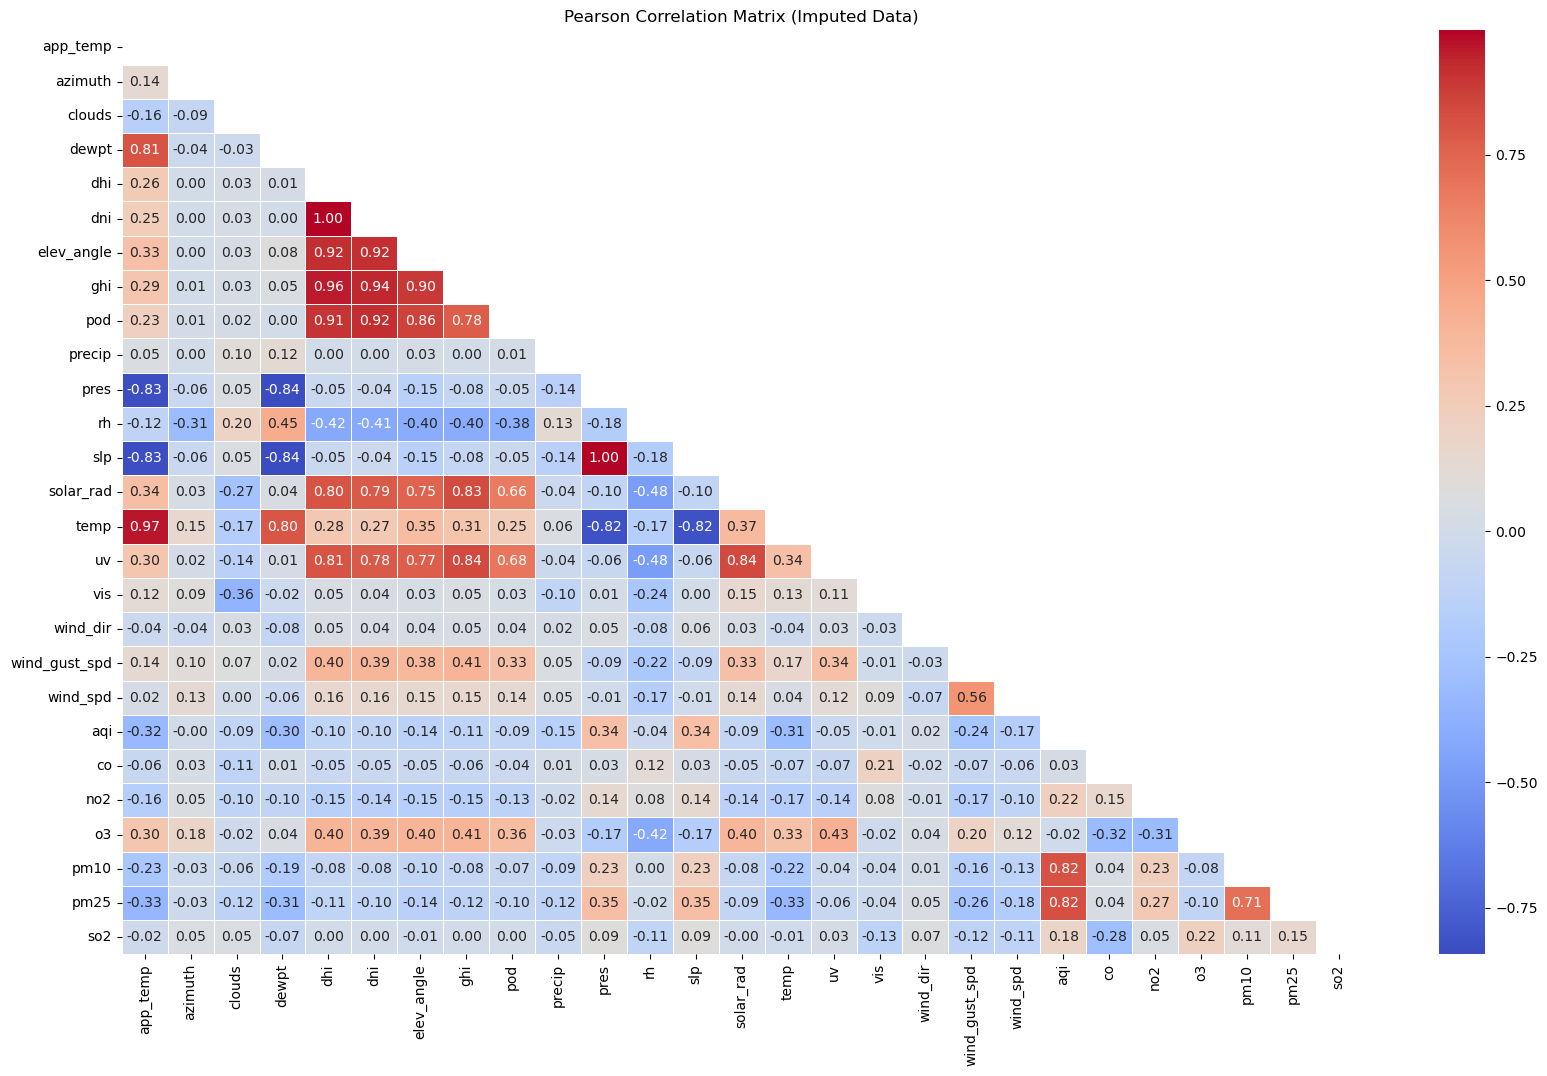

In [29]:
# Generate the Correlation Matrix
plt.figure(figsize=(20, 12))
correlation_matrix = df_final.corr()

# Create a mask to hide the upper triangle for better visualization
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plotting
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Pearson Correlation Matrix (Imputed Data)")
plt.show()

The selection of features for removal is based on two criteria: Strict Statistical Thresholds ($|r| > 0.90$) and Domain-Specific Redundancy (sub-components vs. aggregates).

Primary Redundancies Identified:

| Category | High-Correlation Pair | Decision | Scientific Justification |
|---|---|---|---|
| Pressure | `slp` vs. `pres` ($r$ = 1.00) | Drop `pres` | Sea Level Pressure (`slp`) is the international meteorological standard for tracking air mass movements. |